Project 3 Supervised Classification on German Credit Risk (version 2)

# Assignment Details

**This is a group project with three students at most from CSCI 441 and two students at most from CSCI 541**

**Objectives**:	

•	To train deep MLPs with Keras.

•	To use TensorBoard for visualization

•	To fine-tune neural network hyperparameters with Keras Tuner

**Problem** 

In this project, you will repeat Project 2 to rebuild the classifier for German Credit Risk using MLPs with Keras. 

**Requirements**

Your project and report should contain the following components:
1.	Data Preparation

2.	Model building  

    o	Select the number of hidden layers, the number of neurons on each layer learning rate and other hyperparameters following the suggestions on page 349 ~ 353 and Table 10-2.

    o	display the model’s information including

            o	each layer’s name, its output shape, its number of parameters, and all its parameters;

            o	the total number of parameters including trainable and non-trainable parameters.

3.	Model Training

4.	Model Evaluation

    a)	display learning curves following the Figure 10-11;

    b)	build a visualization tool as Figure 10-16 using TensonBoard and show learning curves again;

    c)	analyze the results.

5.	Prediction

6.	Hyperparameter Tuning

    o	get the hyperparameters for the best model by tuning the hyperparameters using Keras Tuner with all the bells and whistles—save checkpoints, use early stopping, and plot learning curves using TensorBoard.

    o	show the best accuracy.

7.	Conclusion

**What to Hand In**
1.	Each group submits one copy of your project as Jupyter notebook in your class account in GitHub – Project3 by the group leader.
2.	Each group submits one PDF copy of your project to the drop box Project 3 on D2L by the group leader.
3.	All members must submit the assessment forms for other members in the same group as you did before.


# Initializations

In [434]:
import sys

assert sys.version_info >= (3, 7)

In [435]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")


# Get The Data

## Download the Data

We retrieve the dataset as a CSV file from the provided openml website via URL and create a variable `credit_data` to hold the raw data.

In [436]:
from pathlib import Path
import pandas as pd
import urllib.request

def load_credit_data():
    csv_path = Path("../data/german_credit_data.csv")
    if not csv_path.is_file():
        Path("../data").mkdir(parents=True, exist_ok=True)
        url = "https://www.openml.org/data/get_csv/31/dataset_31_german_credit.csv"
        urllib.request.urlretrieve(url, csv_path)
    return pd.read_csv(csv_path)

credit_data = load_credit_data()

## Take a Quick Look

Using shape, we quickly see our dataset’s dimensions: 1000 samples, each with 21 attributes.

In [437]:
credit_data.shape

(1000, 21)

The `head()` function gives us a glimpse of the first few samples in our dataset. It allows us to assess the formatting of our data and begin understanding its structure, helping us to decide how to proceed with our analysis.

In [438]:
credit_data.head(10)

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,'<0',6,'critical/other existing credit',radio/tv,1169,'no known savings','>=7',4,'male single',none,...,'real estate',67,none,own,2,skilled,1,yes,yes,good
1,'0<=X<200',48,'existing paid',radio/tv,5951,'<100','1<=X<4',2,'female div/dep/mar',none,...,'real estate',22,none,own,1,skilled,1,none,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,'<100','4<=X<7',2,'male single',none,...,'real estate',49,none,own,1,'unskilled resident',2,none,yes,good
3,'<0',42,'existing paid',furniture/equipment,7882,'<100','4<=X<7',2,'male single',guarantor,...,'life insurance',45,none,'for free',1,skilled,2,none,yes,good
4,'<0',24,'delayed previously','new car',4870,'<100','1<=X<4',3,'male single',none,...,'no known property',53,none,'for free',2,skilled,2,none,yes,bad
5,'no checking',36,'existing paid',education,9055,'no known savings','1<=X<4',2,'male single',none,...,'no known property',35,none,'for free',1,'unskilled resident',2,yes,yes,good
6,'no checking',24,'existing paid',furniture/equipment,2835,'500<=X<1000','>=7',3,'male single',none,...,'life insurance',53,none,own,1,skilled,1,none,yes,good
7,'0<=X<200',36,'existing paid','used car',6948,'<100','1<=X<4',2,'male single',none,...,car,35,none,rent,1,'high qualif/self emp/mgmt',1,yes,yes,good
8,'no checking',12,'existing paid',radio/tv,3059,'>=1000','4<=X<7',2,'male div/sep',none,...,'real estate',61,none,own,1,'unskilled resident',1,none,yes,good
9,'0<=X<200',30,'critical/other existing credit','new car',5234,'<100',unemployed,4,'male mar/wid',none,...,car,28,none,own,2,'high qualif/self emp/mgmt',1,none,yes,bad


From the data info, we can see there are no missing values across any attributes. Out of 21 attributes, 14 are of "object" data type, indicating a significant number of categorical features. The remaining 7 are "int64", representing integer numerical data.

In [439]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   checking_status         1000 non-null   object
 1   duration                1000 non-null   int64 
 2   credit_history          1000 non-null   object
 3   purpose                 1000 non-null   object
 4   credit_amount           1000 non-null   int64 
 5   savings_status          1000 non-null   object
 6   employment              1000 non-null   object
 7   installment_commitment  1000 non-null   int64 
 8   personal_status         1000 non-null   object
 9   other_parties           1000 non-null   object
 10  residence_since         1000 non-null   int64 
 11  property_magnitude      1000 non-null   object
 12  age                     1000 non-null   int64 
 13  other_payment_plans     1000 non-null   object
 14  housing                 1000 non-null   object
 15  exist

We can use `describe()` and `describe(include=['object'])` to gather statistical data about our dataframe. `describe()` defaults to numerical data, so we will also run `describe(include=['object'])` to gather more information on categorical data.

In [440]:
credit_data.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [441]:
credit_data.describe(include=['object'])

,checking_status,credit_history,purpose,savings_status,employment,personal_status,other_parties,property_magnitude,other_payment_plans,housing,job,own_telephone,foreign_worker,class
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,4,5,10,5,5,4,3,4,3,3,4,2,2,2
top,'no checking','existing paid',radio/tv,'<100','1<=X<4','male single',none,car,none,own,skilled,none,yes,good
freq,394,530,280,603,339,548,907,332,814,713,630,596,963,700


We will now use `value_counts()` to examine each categorical data attribute. This will help us understand the distribution of categories and guide our approach to preprocessing and feature engineering. One way it may help is to aid in identifying imbalances that may generate challenges for the model.

In [442]:
# Identify categorical columns
categorical_columns = credit_data.select_dtypes(include=['object']).columns

# Get value counts for each categorical column
for column in categorical_columns:
    print(f"Value counts for {column}:")
    print(credit_data[column].value_counts())
    print("\n")

Value counts for checking_status:
checking_status
'no checking'    394
'<0'             274
'0<=X<200'       269
'>=200'           63
Name: count, dtype: int64


Value counts for credit_history:
credit_history
'existing paid'                     530
'critical/other existing credit'    293
'delayed previously'                 88
'all paid'                           49
'no credits/all paid'                40
Name: count, dtype: int64


Value counts for purpose:
purpose
radio/tv                280
'new car'               234
furniture/equipment     181
'used car'              103
business                 97
education                50
repairs                  22
'domestic appliance'     12
other                    12
retraining                9
Name: count, dtype: int64


Value counts for savings_status:
savings_status
'<100'                603
'no known savings'    183
'100<=X<500'          103
'500<=X<1000'          63
'>=1000'               48
Name: count, dtype: int64


Value counts f

# Tests

We will apply a stratified split with *"class"* as our label. *"class"* is not only our target variable but also a means to achieve a balanced distribution between the training set and test set. We have determined that a 70/30 split works well for our selected model as the larger test set provides more context for the intricate data set to improve our predictions

In [443]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    credit_data, test_size=0.3, stratify=credit_data["class"], random_state=42)

In [444]:
strat_test_set["class"].value_counts() / len(strat_test_set)

class
good    0.7
bad     0.3
Name: count, dtype: float64

This code compares the *"class"* distribution in the overall dataset, a stratified test set, and a random test set to evaluate how well each sampling method maintains the original proportions. The output shows that stratified sampling perfectly matches the overall class distribution, while random sampling has minor deviations.

In [445]:
def income_cat_proportions(data):
    return data["class"].value_counts() / len(data)

train_set, test_set = train_test_split(credit_data, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(credit_data),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
bad,30.0,30.0,29.5,0.0,-1.67
good,70.0,70.0,70.5,0.0,0.71


# Explore the Data

## Data Prep

We make a copy of the original data to maintain the integrity of the raw data. Then, we use `LabelEncoder()` on our target attribute to convert from categorical to numerical values. This will aid in identifying potential relationships.

In [446]:
credit_data = strat_train_set.copy()

In [447]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoded_class = encoder.fit_transform(credit_data['class'])
credit_data['encoded_class'] = encoded_class

## Looking For Correlations and Analyzing Trends

The scatter matrix reveals that the positive correlation between *duration* and *credit_amount* may influence the target attribute. The distribution of classes in histograms indicates potential class imbalances that need addressing. We will likely have to address some outliers and employ some form of normalization in preprocessing.

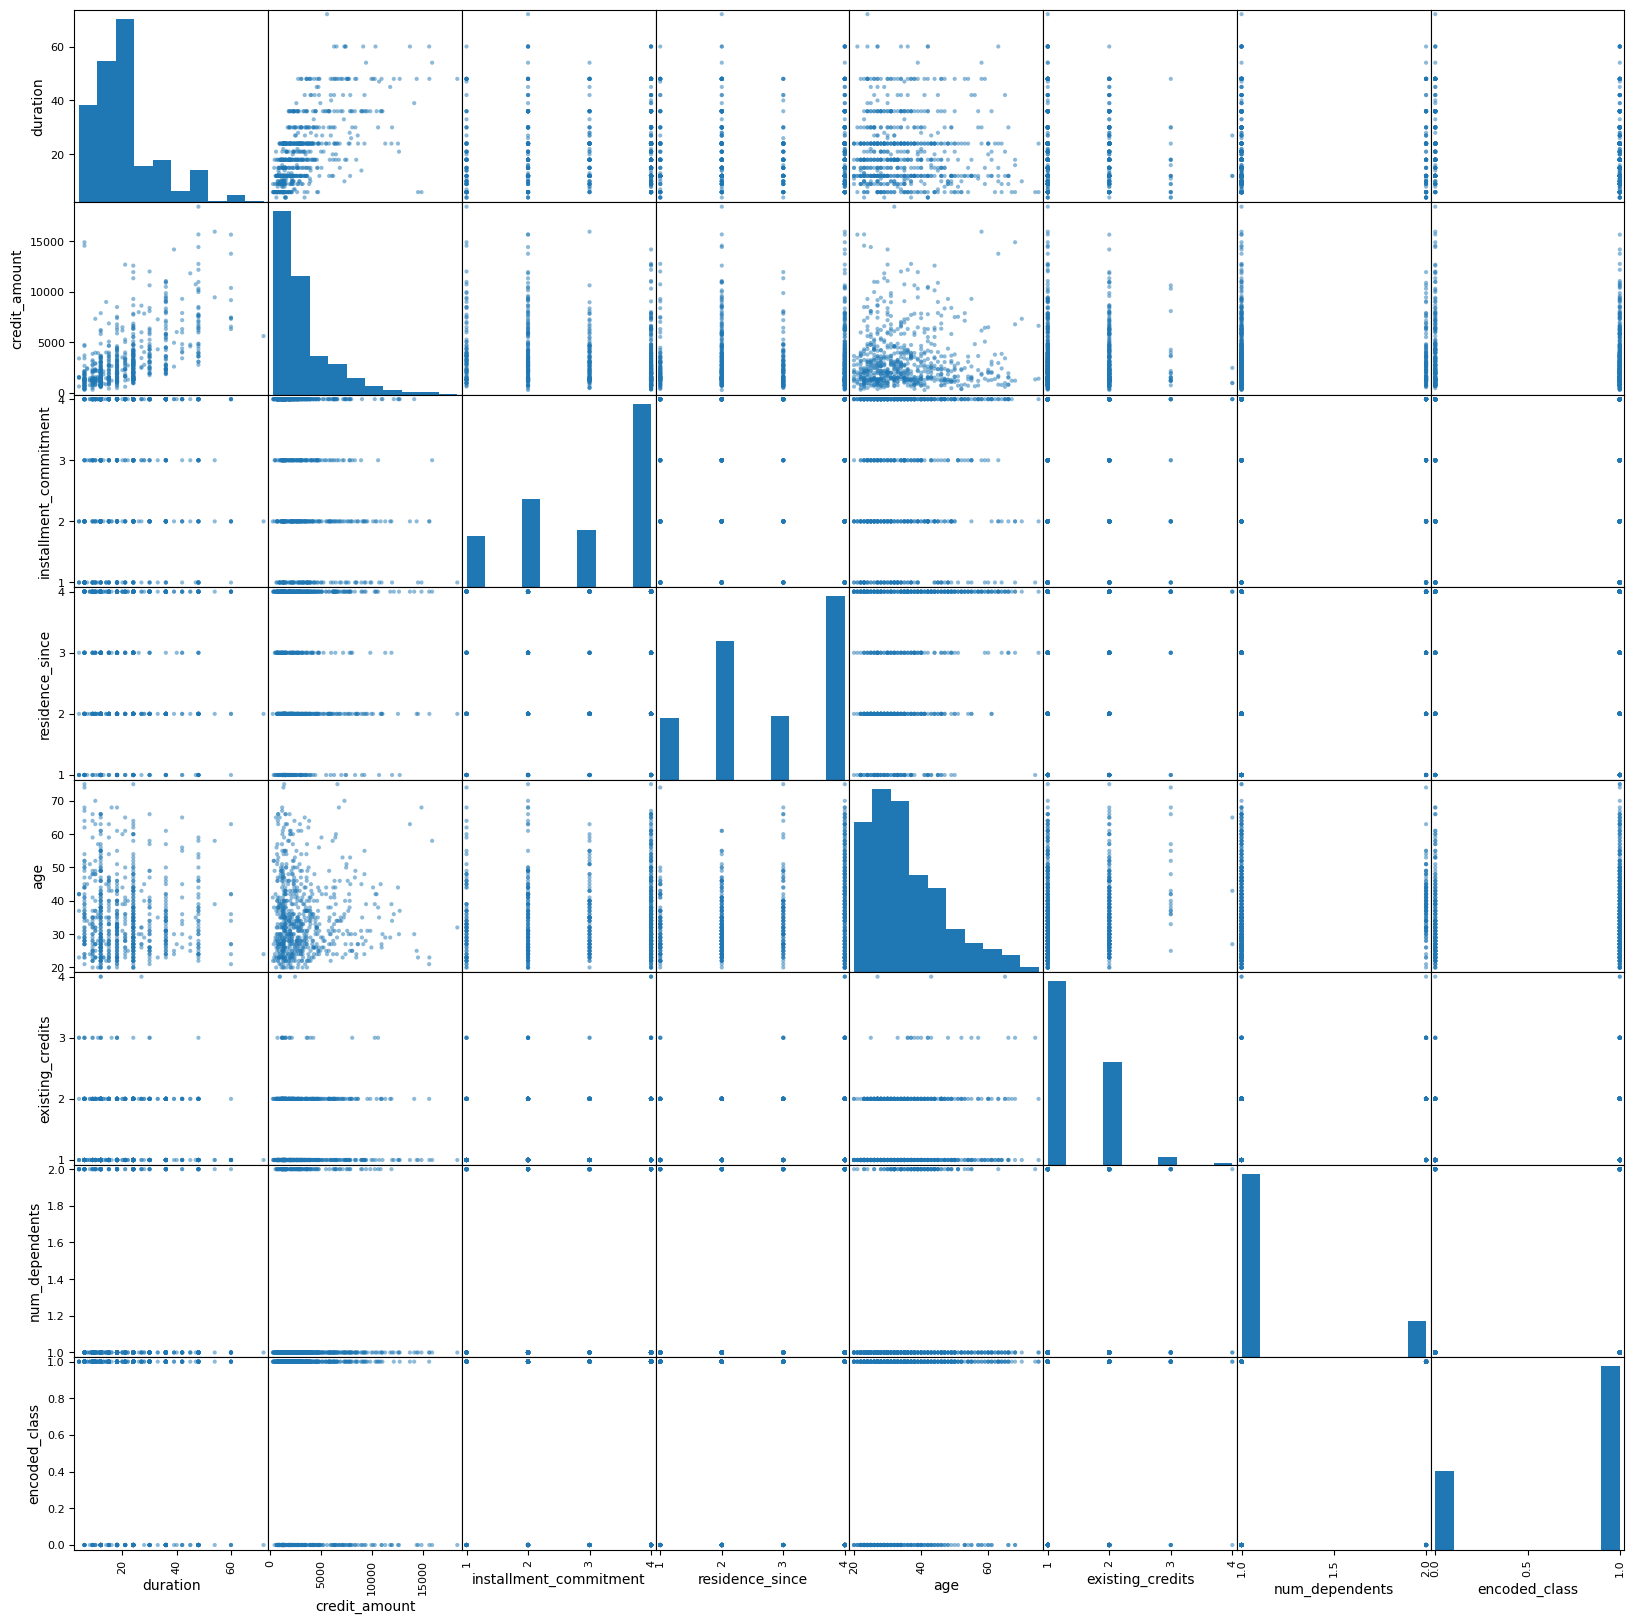

In [448]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

scatter_matrix(credit_data, figsize=(20, 20), alpha=0.5, diagonal='hist')
plt.show()

Isolating this grid square, we can see a moderate positive correlation which may prove important in feature engineering.

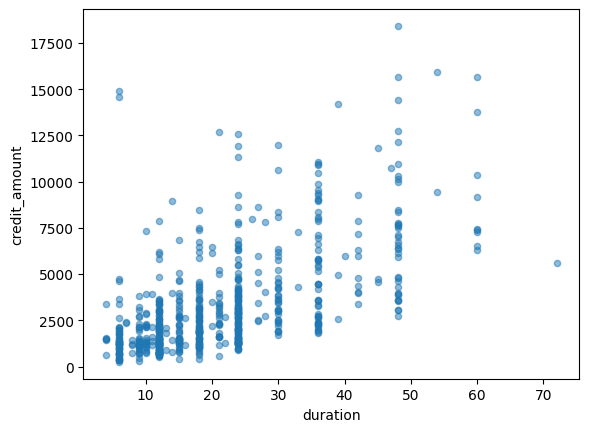

In [449]:
credit_data.plot(kind="scatter", x="duration", y="credit_amount", alpha=0.5)
plt.show()

The correlation matrix helps illustrate that there does not appear to be a single numerical attribute with a strong correlation to our target variables.

In [450]:
corr_matrix = credit_data.corr(numeric_only=True)
print(corr_matrix[['encoded_class']].sort_values(by='encoded_class', ascending=False))

                        encoded_class
encoded_class                1.000000
age                          0.100336
existing_credits             0.087810
num_dependents               0.043903
residence_since             -0.010086
installment_commitment      -0.045049
credit_amount               -0.162453
duration                    -0.216271


This correlation heatmap is more comprehensive and provides information regarding the numerical attribute correlations. These relationships may aid in our feature engineering.

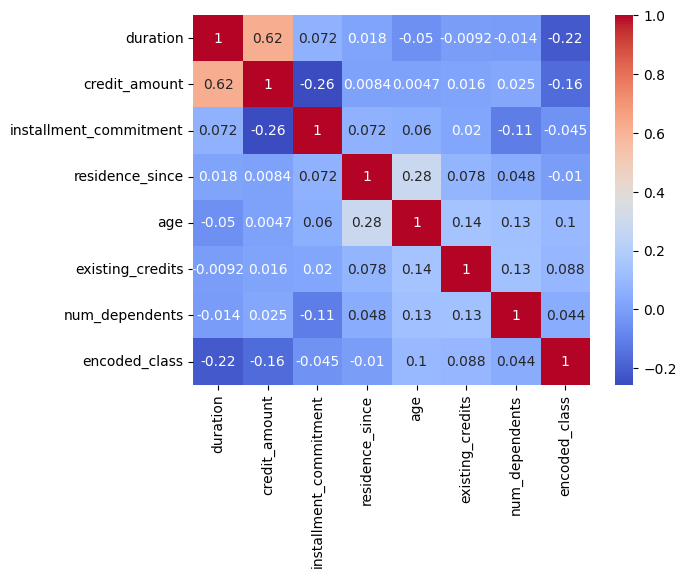

In [451]:
import seaborn as sns

# Select numerical columns for the correlation matrix
numerical_cols = credit_data.select_dtypes(include=['int64', 'float64'])

# Generate the heatmap
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm')
plt.show()

## Experimenting with Attribute Contributions

After reviewing the correlation matrix, we observe that there aren't many strong correlations. To address this, we will explore potential features to uncover stronger relationships between attributes. This step is crucial for enhancing our model's performance by identifying interactions that may not be immediately evident.

In [452]:
credit_data["age_per_credit_amount"] = credit_data["age"] / credit_data["credit_amount"]
credit_data["age_per_duration"] = credit_data["age"] / credit_data["duration"]
credit_data["age_per_installment_commitment"] = credit_data["age"] / credit_data["installment_commitment"]
credit_data["age_per_residence"] = credit_data["age"] / credit_data["residence_since"]
credit_data["age_times_residence"] = credit_data["age"] * credit_data["residence_since"]
credit_data["credit_amount_per_duration"] = credit_data["credit_amount"] / credit_data["duration"]
credit_data["credits_per_duration"] = credit_data["existing_credits"] / credit_data["duration"]
credit_data["credits_per_residence"] = credit_data["existing_credits"] / credit_data["residence_since"]
credit_data["dependents_times_credits"] = credit_data["num_dependents"] * credit_data["existing_credits"]
credit_data["duration_per_credit_amount"] = credit_data["duration"] / credit_data["credit_amount"]
credit_data["duration_per_dependent"] = credit_data["duration"] / (credit_data["num_dependents"] + 1)
credit_data["duration_per_residence"] = credit_data["duration"] / credit_data["residence_since"]
credit_data["installment_commitment_adjusted"] = credit_data["installment_commitment"] / credit_data["credit_amount"]
credit_data["installment_commitment_ratio"] = credit_data["installment_commitment"] / credit_data["duration"]
credit_data["installments_per_dependent"] = credit_data["installment_commitment"] / (credit_data["num_dependents"] + 1)
credit_data["installments_per_duration"] = credit_data["installment_commitment"] / credit_data["duration"]
credit_data["installments_per_residence"] = credit_data["installment_commitment"] / credit_data["residence_since"]
credit_data["residence_per_age"] = credit_data["residence_since"] / credit_data["age"]

In [453]:
corr_matrix = credit_data.corr(numeric_only=True)
print(corr_matrix[['encoded_class']].sort_values(by='encoded_class', ascending=False))

                                 encoded_class
encoded_class                         1.000000
credits_per_duration                  0.196913
age_per_duration                      0.195347
installment_commitment_ratio          0.141901
installments_per_duration             0.141901
age_per_credit_amount                 0.101264
age                                   0.100336
existing_credits                      0.087810
credits_per_residence                 0.084155
age_per_residence                     0.082279
dependents_times_credits              0.080135
age_per_installment_commitment        0.077764
age_times_residence                   0.050035
num_dependents                        0.043903
installment_commitment_adjusted       0.037024
installments_per_residence            0.003295
residence_since                      -0.010086
installment_commitment               -0.045049
installments_per_dependent           -0.046798
credit_amount_per_duration           -0.047117
residence_per

We now drop the encoded attribute that we created. It has served its purpose and will affect our data preparation if not removed.

In [454]:
# Drop the encoded class column
credit_data = credit_data.drop(columns=['encoded_class'])

# Prepare the Data for Machine Learning Algorithms

In [455]:
credit_data = strat_train_set.drop("class", axis=1)
credit_labels = strat_train_set["class"].copy()

## Data Cleaning

We confirm that there are no missing values.

In [456]:
null_rows_idx = credit_data.isnull().any(axis=1)
credit_data.loc[null_rows_idx].head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker


Earlier, we identified that the following categories were highly imbalanced and had many instances of a single value. These attributes were dropped as they could contribute to noise rather than providing valuable information for the model:

- **other_parties**: The vast majority of values were "none" (907 out of 1000), making it not very informative.
- **foreign_worker**: Most values were "yes" (963 out of 1000), showing little variability.
- **other_payment_plans**: The majority were "none" (814 out of 1000), indicating low diversity in this attribute.

Removing these attributes helps to reduce noise and improve the model’s performance by focusing on more informative and varied features.

In [457]:
drop_columns = ["other_parties", "foreign_worker", "other_payment_plans"]
credit_data = credit_data.drop(columns=drop_columns)

print(credit_data.select_dtypes(include=['object']).head())

    checking_status                    credit_history   purpose  \
328         '>=200'                   'existing paid'  radio/tv   
891   'no checking'  'critical/other existing credit'  radio/tv   
255      '0<=X<200'              'delayed previously'  radio/tv   
243   'no checking'  'critical/other existing credit'  business   
492   'no checking'  'critical/other existing credit'  radio/tv   

         savings_status employment       personal_status property_magnitude  \
328              '<100'      '>=7'         'male single'                car   
891              '<100'      '>=7'         'male single'                car   
255  'no known savings'   '1<=X<4'         'male single'      'real estate'   
243              '<100'   '1<=X<4'  'female div/dep/mar'      'real estate'   
492        '100<=X<500'   '1<=X<4'  'female div/dep/mar'   'life insurance'   

    housing                   job own_telephone  
328     own               skilled          none  
891     own           

We will address the outliers. On the initial run, we noticed that `IsolationForest()` removed too much of the data. To control this better, we set the *contamination* parameter to 0.12, which will hard code the range of outliers to be removed.

In [458]:
from sklearn.ensemble import IsolationForest
import numpy as np

X = credit_data.select_dtypes(include=[np.number])
isolation_forest = IsolationForest(contamination=0.12, random_state=42)
outlier_pred = isolation_forest.fit_predict(X)

In [459]:
outlier_pred

array([ 1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1,  1,
        1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

Now that the outliers are removed, we apply the changes back to the working dataset and labels.

In [460]:
credit_data = credit_data.iloc[outlier_pred == 1]
credit_labels = credit_labels.iloc[outlier_pred == 1]

## Transformation Pipelines

This comprehensive pipeline will handle the cleaned data and prepare it for usage.

In [461]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),  # Using log1p to handle zero values
    StandardScaler()
)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    OrdinalEncoder(),
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(drop='first')
)

preprocessing = ColumnTransformer(
    transformers=[
        ("num", default_num_pipeline, make_column_selector(dtype_include=np.number)),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
        ("log", log_pipeline, ["credit_amount", "duration", "age", "existing_credits", "num_dependents"]),
        #
        ("credit_amount_per_existing_credits", ratio_pipeline(), ["credit_amount", "existing_credits"]),
        ("installment_commitment_per_existing_credits", ratio_pipeline(), ["installment_commitment", "existing_credits"]),
        ("duration_per_credit_amount", ratio_pipeline(), ["duration", "credit_amount"]),
        ("age_per_duration", ratio_pipeline(), ["age", "duration"]),
        ("credits_per_duration", ratio_pipeline(), ["existing_credits", "duration"]),
        ("installments_per_duration", ratio_pipeline(), ["installment_commitment", "duration"]),
        ("age_per_credit_amount", ratio_pipeline(), ["age", "credit_amount"]),
        ("credits_per_residence", ratio_pipeline(), ["existing_credits", "residence_since"])
    ],
    remainder=default_num_pipeline
)

We now examine the number of samples and the expanded feature set post-preprocessing. This step helps us verify that our transformations and feature engineering steps were applied correctly.

In [462]:
credit_data_prepared = preprocessing.fit_transform(credit_data)
credit_data_prepared.shape

(616, 56)

We can take a look at the names of our generated features. This will be beneficial when viewing feature importance.

In [463]:
preprocessing.get_feature_names_out()

array(['num__duration', 'num__credit_amount',
       'num__installment_commitment', 'num__residence_since', 'num__age',
       'num__existing_credits', 'num__num_dependents',
       'cat__checking_status_1.0', 'cat__checking_status_2.0',
       'cat__checking_status_3.0', 'cat__credit_history_1.0',
       'cat__credit_history_2.0', 'cat__credit_history_3.0',
       'cat__credit_history_4.0', 'cat__purpose_1.0', 'cat__purpose_2.0',
       'cat__purpose_3.0', 'cat__purpose_4.0', 'cat__purpose_5.0',
       'cat__purpose_6.0', 'cat__purpose_7.0', 'cat__purpose_8.0',
       'cat__purpose_9.0', 'cat__savings_status_1.0',
       'cat__savings_status_2.0', 'cat__savings_status_3.0',
       'cat__savings_status_4.0', 'cat__employment_1.0',
       'cat__employment_2.0', 'cat__employment_3.0',
       'cat__employment_4.0', 'cat__personal_status_1.0',
       'cat__personal_status_2.0', 'cat__personal_status_3.0',
       'cat__property_magnitude_1.0', 'cat__property_magnitude_2.0',
       'cat__pro

# Model Building

In [464]:
import tensorflow as tf
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

# Process the data first
credit_data_prepared = preprocessing.fit_transform(credit_data)
y_train = credit_labels.map({'bad': 0, 'good': 1})

def create_model(units_input=100, dropout_input=0.3, units_hidden=50, dropout_hidden=0.3, learning_rate=0.001):
    model = tf.keras.Sequential()
    
    # Input layer
    model.add(tf.keras.layers.Dense(
        units_input,
        activation='relu',
        input_shape=(credit_data_prepared.shape[1],)
    ))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(dropout_input))
    
    # Hidden layer
    model.add(tf.keras.layers.Dense(
        units_hidden,
        activation='relu'
    ))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(dropout_hidden))
    
    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = create_model()

model.summary()

.venv\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                │ (None, 100)            │         5,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,401 (44.54 KB)

 Trainable params: 11,101 (43.36 KB)

 Non-trainable params: 300 (1.17 KB)

## Training

In [465]:
history = model.fit(credit_data_prepared, y_train, epochs=30, batch_size=32, validation_split=0.2)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5001 - loss: 0.9307 - val_accuracy: 0.6290 - val_loss: 0.6459
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6374 - loss: 0.7386 - val_accuracy: 0.7177 - val_loss: 0.6097
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6531 - loss: 0.6286 - val_accuracy: 0.7177 - val_loss: 0.5921
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6786 - loss: 0.6338 - val_accuracy: 0.7177 - val_loss: 0.5824
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7716 - loss: 0.4988 - val_accuracy: 0.7258 - val_loss: 0.5666
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7688 - loss: 0.5316 - val_accuracy: 0.7177 - val_loss: 0.5558
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7441 - loss: 0.5270 - val_accuracy: 0.7177 - val_loss: 0.5481
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7895 - loss: 0.4426 - val_accuracy: 0.7177 - val_loss

## Evaluation

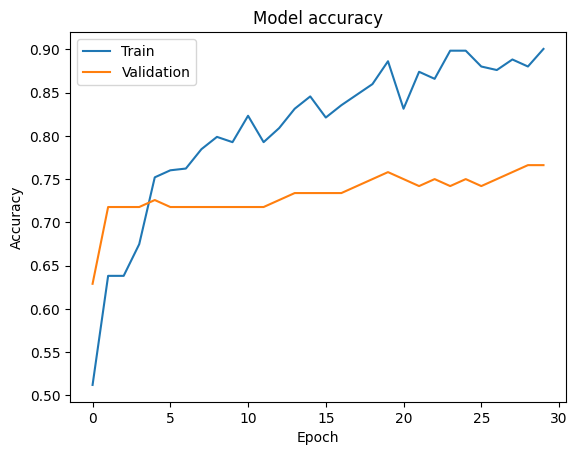

In [466]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


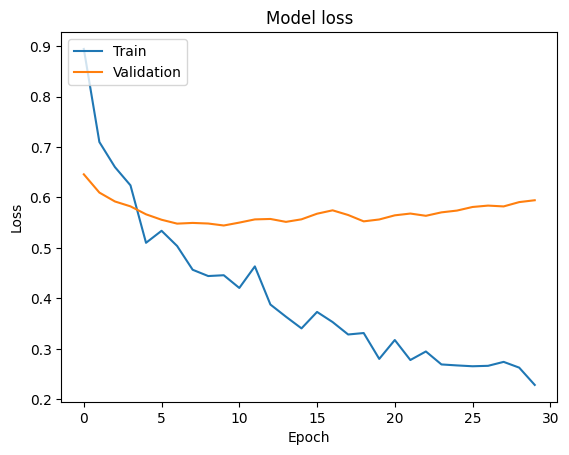

In [467]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [468]:
test_data_prepared = preprocessing.transform(strat_test_set.drop("class", axis=1))
y_test = strat_test_set["class"].map({'bad': 0, 'good': 1}).copy()

test_loss, test_accuracy = model.evaluate(test_data_prepared, y_test)
print(f"Test Accuracy: {test_accuracy}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7214 - loss: 0.7301 
Test Accuracy: 0.7300000190734863


### TensorBoard

In [ ]:
import tensorflow as tf
import datetime
import os
import pathlib
import shutil

if os.path.exists("logs"):
    shutil.rmtree("logs")

log_dir = pathlib.Path("logs") / "fit" / datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir.mkdir(parents=True, exist_ok=True)
log_dir_str = str(log_dir).replace("\\", "/") # Needed for Windows VS Code. Remove if using Linux Bash

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir_str,
    histogram_freq=1,
    write_graph=True,
    update_freq='epoch'
)

class DetailedTensorBoardCallback(tf.keras.callbacks.Callback):
    def __init__(self, log_dir):
        super(DetailedTensorBoardCallback, self).__init__()
        self.file_writer = tf.summary.create_file_writer(str(log_dir / 'metrics').replace("\\", "/"))
        
    def on_epoch_end(self, epoch, logs=None):
        with self.file_writer.as_default():
            for name, value in logs.items():
                tf.summary.scalar(name, value, step=epoch)
            self.file_writer.flush()

detailed_tb_callback = DetailedTensorBoardCallback(log_dir)

model = create_model()
history = model.fit(
    credit_data_prepared,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[tensorboard_callback, detailed_tb_callback],
    verbose=1
)

Epoch 1/30


.venv\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4469 - loss: 1.0980 - val_accuracy: 0.6452 - val_loss: 0.6535
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5736 - loss: 0.7408 - val_accuracy: 0.7177 - val_loss: 0.6064
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7059 - loss: 0.5984 - val_accuracy: 0.7500 - val_loss: 0.5929
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7126 - loss: 0.6103 - val_accuracy: 0.7097 - val_loss: 0.5810
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6839 - loss: 0.6283 - val_accuracy: 0.7339 - val_loss: 0.5634
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7897 - loss: 0.4836 - val_accuracy: 0.7097 - val_loss: 0.5545
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7722 - loss: 0.5063 - val_accuracy: 0.7177 - val_loss: 0.5429
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7656 - loss: 0.4992 - val_accuracy: 0.7258 - val_loss: 0.5348
Ep

In [470]:
print("\nVerifying log files...")
event_files = list(pathlib.Path(log_dir).rglob("events.out.tfevents.*"))
for file in event_files:
    print(f"Found log file: {file.as_posix()}")
    print(f"File size: {file.stat().st_size} bytes")

print("\nTensorBoard log directory:")
print(f"Full path: {pathlib.Path(log_dir).absolute().as_posix()}")


Verifying log files...
Found log file: logs/fit/20241203-233133/metrics/events.out.tfevents.1733290293.HOST.125708.130.v2
File size: 7990 bytes
Found log file: logs/fit/20241203-233133/train/events.out.tfevents.1733290293.HOST.125708.131.v2
File size: 351062 bytes
Found log file: logs/fit/20241203-233133/validation/events.out.tfevents.1733290294.HOST.125708.132.v2
File size: 9660 bytes

TensorBoard log directory:
Full path: logs/fit/20241203-233133


In [471]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [472]:
%tensorboard --logdir {str(log_dir).replace('\\', '/')}

### Performance

In [473]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

y_pred_proba = model.predict(test_data_prepared)
y_pred = (y_pred_proba > 0.5).astype(int)

# Calculate all metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print all scores
print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Model Performance Metrics:
Accuracy: 0.7167
Precision: 0.7572
Recall: 0.8762
F1 Score: 0.8124
ROC AUC Score: 0.7129


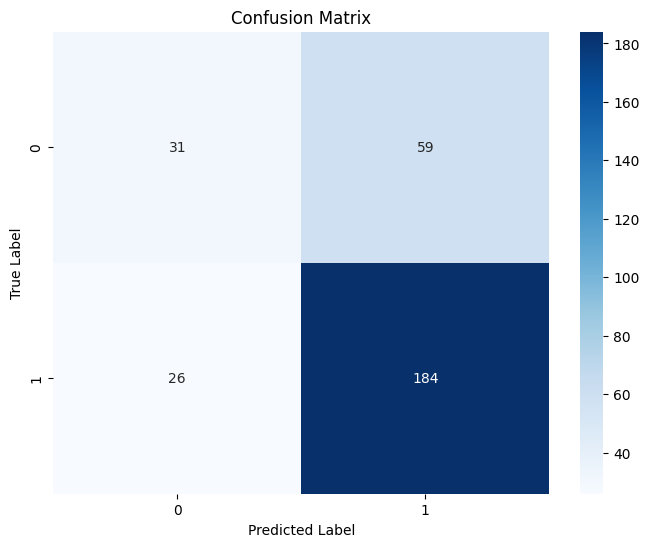

In [474]:
# Create and plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [475]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.34      0.42        90
           1       0.76      0.88      0.81       210

    accuracy                           0.72       300
   macro avg       0.65      0.61      0.62       300
weighted avg       0.69      0.72      0.70       300



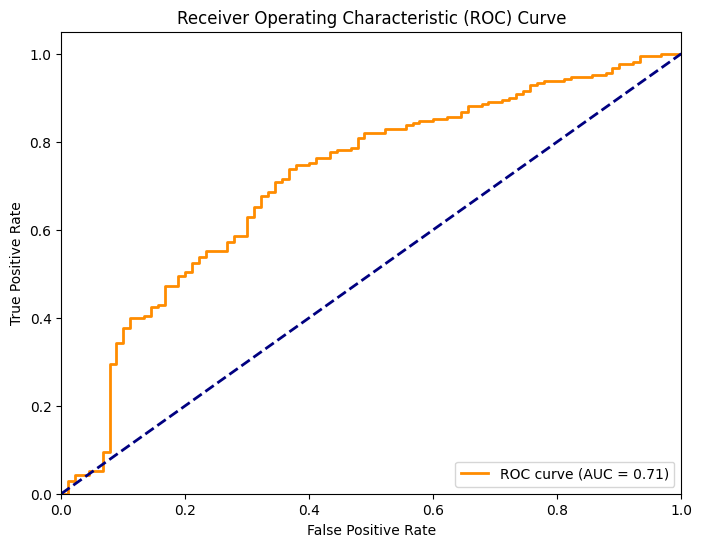

In [476]:
# Plot ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Fine Tuning

In [477]:
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime
import pathlib

predictions = model.predict(credit_data_prepared)
predicted_classes = (predictions > 0.5).astype(int)

print("\nCurrent Model Performance:")
print(f"Train Accuracy: {model.evaluate(credit_data_prepared, y_train)[1]:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

Current Model Performance:
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9295 - loss: 0.1827 
Train Accuracy: 0.8799


## Tuning Model

In [478]:
class CreditModelTuner(kt.HyperModel):
    def build(self, hp):
        model = tf.keras.Sequential()
        
        # Tune input layer
        units_input = hp.Int('units_input', min_value=32, max_value=256, step=32)
        dropout_input = hp.Float('dropout_input', min_value=0.1, max_value=0.5, step=0.1)
        
        model.add(tf.keras.layers.Dense(
            units_input,
            activation='relu',
            input_shape=(credit_data_prepared.shape[1],)
        ))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Dropout(dropout_input))
        
        # Tune hidden layer
        units_hidden = hp.Int('units_hidden', min_value=16, max_value=128, step=16)
        dropout_hidden = hp.Float('dropout_hidden', min_value=0.1, max_value=0.5, step=0.1)
        
        model.add(tf.keras.layers.Dense(
            units_hidden,
            activation='relu'
        ))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Dropout(dropout_hidden))
        
        # Output layer
        model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
        
        # Tune learning rate
        learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        
        return model
    
    def fit(self, hp, model, *args, **kwargs):
        return model.fit(
            *args,
            **kwargs
        )

## Tuning

In [479]:
tuner = kt.BayesianOptimization(
    CreditModelTuner(),
    objective='val_accuracy',
    max_trials=30,
    directory='credit_tuning',
    project_name='german_credit'
)

Reloading Tuner from credit_tuning\german_credit\tuner0.json


In [480]:
tuning_log_dir = pathlib.Path("logs") / "tuning" / datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tuning_log_dir.mkdir(parents=True, exist_ok=True)

In [481]:
tuning_callbacks = [
    TensorBoard(
        log_dir=str(tuning_log_dir / "tensorboard"),
        histogram_freq=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

In [482]:
print("\nStarting hyperparameter tuning...")
tuner.search(
    credit_data_prepared,
    y_train,
    epochs=30,
    validation_split=0.2,
    callbacks=tuning_callbacks
)


Starting hyperparameter tuning...


In [483]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters:")
print(f"Input Units: {best_hps.get('units_input')}")
print(f"Input Dropout: {best_hps.get('dropout_input')}")
print(f"Hidden Units: {best_hps.get('units_hidden')}")
print(f"Hidden Dropout: {best_hps.get('dropout_hidden')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")


Best Hyperparameters:
Input Units: 192
Input Dropout: 0.30000000000000004
Hidden Units: 16
Hidden Dropout: 0.5
Learning Rate: 0.0007359237843776363


# Final Model

In [484]:
best_model = tuner.hypermodel.build(best_hps)

history1 = best_model.fit(
    credit_data_prepared,
    y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=tuning_callbacks
)

history = {
    'accuracy': history1.history['accuracy'],
    'val_accuracy': history1.history['val_accuracy'],
    'loss': history1.history['loss'], 
    'val_loss': history1.history['val_loss']
}

Epoch 1/20


.venv\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4522 - loss: 1.0362 - val_accuracy: 0.5726 - val_loss: 0.6677
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5115 - loss: 0.8585 - val_accuracy: 0.6371 - val_loss: 0.6443
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6138 - loss: 0.6995 - val_accuracy: 0.7097 - val_loss: 0.6196
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6484 - loss: 0.6535 - val_accuracy: 0.7339 - val_loss: 0.6053
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6595 - loss: 0.6427 - val_accuracy: 0.7500 - val_loss: 0.5896
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5786 - loss: 0.6952 - val_accuracy: 0.7581 - val_loss: 0.5724
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6953 - loss: 0.6017 - val_accuracy: 0.7742 - val_loss: 0.5573
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7508 - loss: 0.5407 - val_accuracy: 0.7903 - val_loss: 0.5443
Ep

In [485]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_proba = best_model.predict(test_data_prepared)
y_pred = (y_pred_proba > 0.5).astype(int)

conf_matrix = confusion_matrix(y_test, y_pred)  
roc_auc = roc_auc_score(y_test, y_pred_proba)  
class_report = classification_report(y_test, y_pred, output_dict=True) 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [486]:
print("\nBest Model Performance on Test Data:")  
print(f"Best Validation Accuracy: {max(history['val_accuracy']):.4f}")
print(f"\nROC AUC Score: {roc_auc:.4f}")
print(f"Precision: {class_report['1']['precision']:.4f}")
print(f"Recall: {class_report['1']['recall']:.4f}")
print(f"F1 Score: {class_report['1']['f1-score']:.4f}")


Best Model Performance on Test Data:
Best Validation Accuracy: 0.8226

ROC AUC Score: 0.7295
Precision: 0.7830
Recall: 0.8762
F1 Score: 0.8270


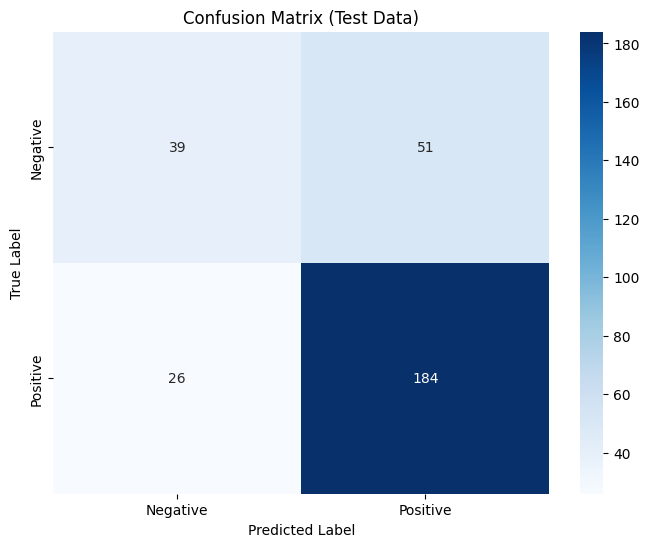

In [487]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix (Test Data)') 
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [488]:
print("\nDetailed Classification Report (Test Data):")
print(classification_report(y_test, y_pred))


Detailed Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.60      0.43      0.50        90
           1       0.78      0.88      0.83       210

    accuracy                           0.74       300
   macro avg       0.69      0.65      0.67       300
weighted avg       0.73      0.74      0.73       300



In [489]:
tn, fp, fn, tp = conf_matrix.ravel()
print("\nAdditional Metrics (Test Data):")
print(f"False Positive Rate: {fp/(fp+tn):.4f}")
print(f"False Negative Rate: {fn/(fn+tp):.4f}")
print(f"True Positive Rate (Sensitivity): {tp/(tp+fn):.4f}")
print(f"True Negative Rate (Specificity): {tn/(tn+fp):.4f}")


Additional Metrics (Test Data):
False Positive Rate: 0.5667
False Negative Rate: 0.1238
True Positive Rate (Sensitivity): 0.8762
True Negative Rate (Specificity): 0.4333


In [490]:
best_model.save('../models/best_german_credit_model.h5')
print("\nBest model saved as '../models/best_german_credit_model.h5'")


Best model saved as 'best_german_credit_model.h5'


In [491]:
try:
    print("\nView tuning results in TensorBoard:")
    %tensorboard --logdir {str(log_dir).replace('\\', '/')}
except:
    print(f"\nTo view tuning results in TensorBoard, run:")
    print(f"tensorboard --logdir {str(log_dir)}")


View tuning results in TensorBoard:


Reusing TensorBoard on port 6019 (pid 138964), started 0:00:04 ago. (Use '!kill 138964' to kill it.)